# Fase 3 — Análise Exploratória (EDA)
**Projeto:** Deriva de Pauta nas Notícias do CNJ

Objetivo: caracterizar o acervo coletado antes da modelagem de tópicos —
volume por mês e por categoria-fonte, distribuição de comprimento dos textos,
termos mais frequentes e nuvem de palavras.

Entrada: `data/interim/noticias_limpo.parquet` (Fase 2). Figuras salvas em
`reports/figures/`.

In [1]:
import sys
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130,
                     "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})

df = pd.read_parquet(ROOT / "data" / "interim" / "noticias_limpo.parquet")
df["data_publicacao"] = pd.to_datetime(df["data_publicacao"])
print("Notícias:", len(df))
print("Período:", df["data_publicacao"].min().date(), "->", df["data_publicacao"].max().date())
df.head(3)[["data_publicacao", "titulo", "n_tokens"]]

Notícias: 979
Período: 2025-12-22 -> 2026-06-19


,data_publicacao,titulo,n_tokens
0,2026-06-19 12:12:21,CNJ recebe inscrições para edital de nacionali...,435
1,2026-06-19 11:15:39,Exposição permanente resgata a história dos Ju...,676
2,2026-06-19 10:46:24,"Recorde: TJTO arrecada 2,5 toneladas de tampin...",154


## 1. Volume por mês

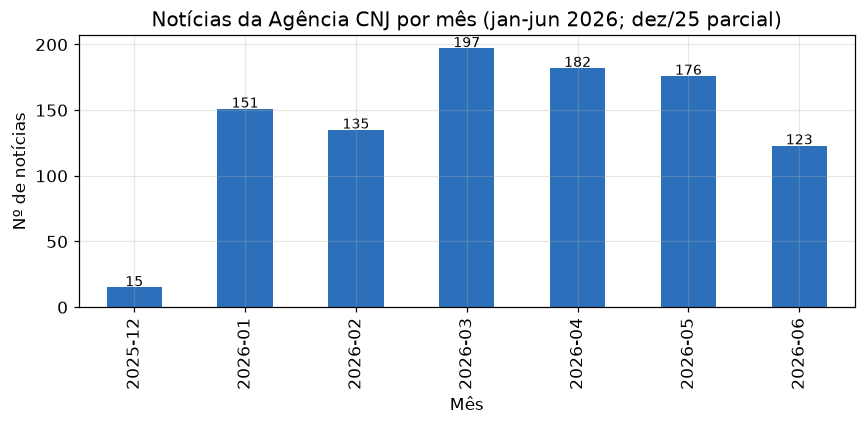

mes
2025-12     15
2026-01    151
2026-02    135
2026-03    197
2026-04    182
2026-05    176
2026-06    123
Name: count, dtype: int64

In [2]:
vol_mes = df["mes"].value_counts().sort_index()
ax = vol_mes.plot(kind="bar", color="#2c6fbb", figsize=(8, 4))
ax.set_title("Notícias da Agência CNJ por mês (jan-jun 2026; dez/25 parcial)")
ax.set_xlabel("Mês"); ax.set_ylabel("Nº de notícias")
for i, v in enumerate(vol_mes):
    ax.text(i, v + 1, str(v), ha="center", fontsize=9)
plt.tight_layout(); plt.savefig(FIG / "01_volume_por_mes.png"); plt.show()
vol_mes

## 2. Volume por categoria-fonte

As categorias editoriais são poucas e genéricas — quase todo o acervo recai em
2-3 rótulos. Isso motiva a modelagem de tópicos não supervisionada (a taxonomia
existente não revela a pauta fina). Uma notícia pode ter mais de uma categoria.

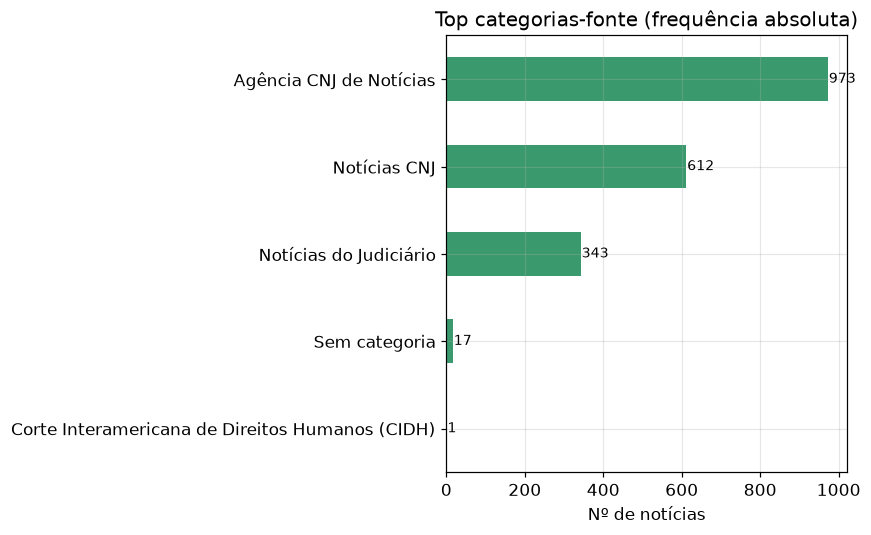

Agência CNJ de Notícias                            973
Notícias CNJ                                       612
Notícias do Judiciário                             343
Sem categoria                                       17
Corte Interamericana de Direitos Humanos (CIDH)      1
dtype: int64

In [3]:
cat = Counter()
for cats in df["categoria_fonte"]:
    for k in (cats if cats is not None else []):
        cat[k] += 1
cat_s = pd.Series(cat).sort_values(ascending=True).tail(12)
ax = cat_s.plot(kind="barh", color="#3a9a6d", figsize=(8, 5))
ax.set_title("Top categorias-fonte (frequência absoluta)")
ax.set_xlabel("Nº de notícias")
for i, v in enumerate(cat_s):
    ax.text(v + 2, i, str(v), va="center", fontsize=9)
plt.tight_layout(); plt.savefig(FIG / "02_volume_por_categoria.png"); plt.show()
cat_s.sort_values(ascending=False)

## 3. Distribuição de comprimento dos textos

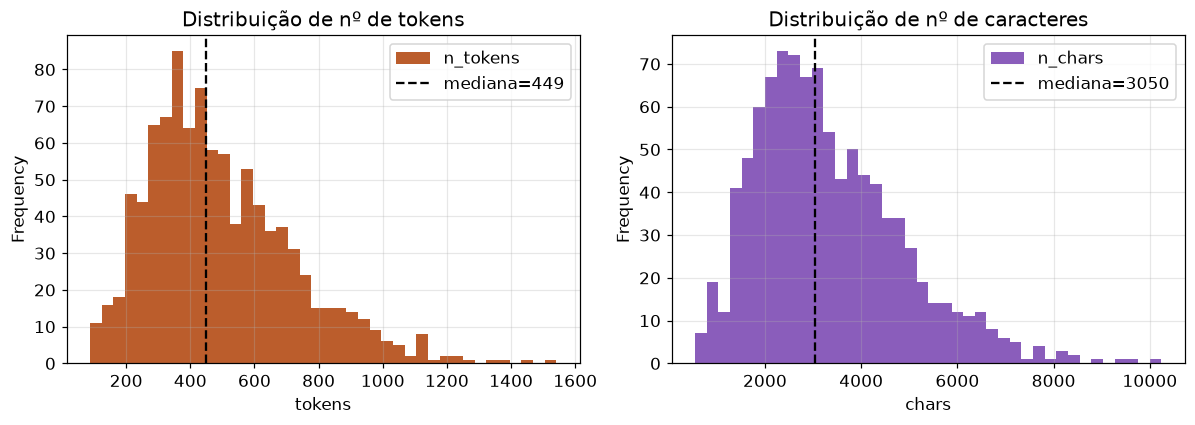

,n_tokens,n_chars
count,979.0,979.0
mean,496.1,3334.0
std,228.9,1533.8
min,87.0,547.0
25%,331.5,2215.5
50%,449.0,3050.0
75%,627.0,4215.5
max,1541.0,10240.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["n_tokens"].plot(kind="hist", bins=40, ax=axes[0], color="#bb5d2c")
axes[0].axvline(df["n_tokens"].median(), color="k", ls="--",
                label=f"mediana={int(df['n_tokens'].median())}")
axes[0].set_title("Distribuição de nº de tokens"); axes[0].set_xlabel("tokens")
axes[0].legend()
df["n_chars"].plot(kind="hist", bins=40, ax=axes[1], color="#8a5dbb")
axes[1].axvline(df["n_chars"].median(), color="k", ls="--",
                label=f"mediana={int(df['n_chars'].median())}")
axes[1].set_title("Distribuição de nº de caracteres"); axes[1].set_xlabel("chars")
axes[1].legend()
plt.tight_layout(); plt.savefig(FIG / "03_distribuicao_comprimento.png"); plt.show()
df[["n_tokens", "n_chars"]].describe().round(1)

## 4. Termos mais frequentes

Contagem sobre o texto normalizado (`corpo_norm`), removendo stopwords do
português (NLTK) e um conjunto institucional de termos onipresentes
(ex.: *cnj*, *justiça*, *tribunal*) que, de tão frequentes, não discriminam
pauta. Mostramos unigramas e bigramas.

In [5]:
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

STOP = set(stopwords.words("portuguese"))
# Termos institucionais/onipresentes que não discriminam pauta:
DOMAIN_STOP = {
    "cnj", "conselho", "nacional", "justica", "justiça", "judiciario",
    "judiciário", "tribunal", "tribunais", "poder", "brasil", "brasileiro",
    "brasileira", "país", "pais", "ainda", "sobre", "durante", "ser", "após",
    "apos", "todos", "todas", "além", "alem", "dia", "dias", "ano", "anos",
    "mês", "mes", "meses", "secao", "seção", "presidente", "ministro",
    "ministra", "federal", "estado", "estadual", "geral", "primeira",
    "segundo", "segunda", "número", "numero", "parte", "forma", "meio",
    "grande", "maior", "novo", "nova", "novos", "novas", "três", "tres",
    "dois", "duas", "the", "of",
}
ALL_STOP = STOP | DOMAIN_STOP

def tokens(text):
    return [w for w in text.split() if len(w) > 2 and w not in ALL_STOP]

uni = Counter()
bi = Counter()
for t in df["corpo_norm"]:
    ws = tokens(t)
    uni.update(ws)
    bi.update(f"{a} {b}" for a, b in zip(ws, ws[1:]))

top_uni = pd.Series(dict(uni.most_common(20)))
top_bi = pd.Series(dict(bi.most_common(20)))
print("Top 20 unigramas:"); print(top_uni)
print("\nTop 20 bigramas:"); print(top_bi)

Top 20 unigramas:
trabalho         1483
sistema          1338
direitos          940
pessoas           938
saúde             867
programa          866
ações             850
iniciativa        797
violência         775
acesso            732
dados             713
processos         711
atuação           699
proteção          667
feira             646
institucional     607
pública           602
social            596
gestão            588
público           586
dtype: int64

Top 20 bigramas:
direitos humanos           417
ministério público         263
crianças adolescentes      263
auxiliar presidência       232
inteligência artificial    219
violência doméstica        206
edson fachin               190
políticas públicas         189
supremo stf                183
pena justa                 177
terça feira                174
sistema prisional          173
superior trabalho          165
juíza auxiliar             160
violência contra           154
defensoria pública         153
boas práticas  

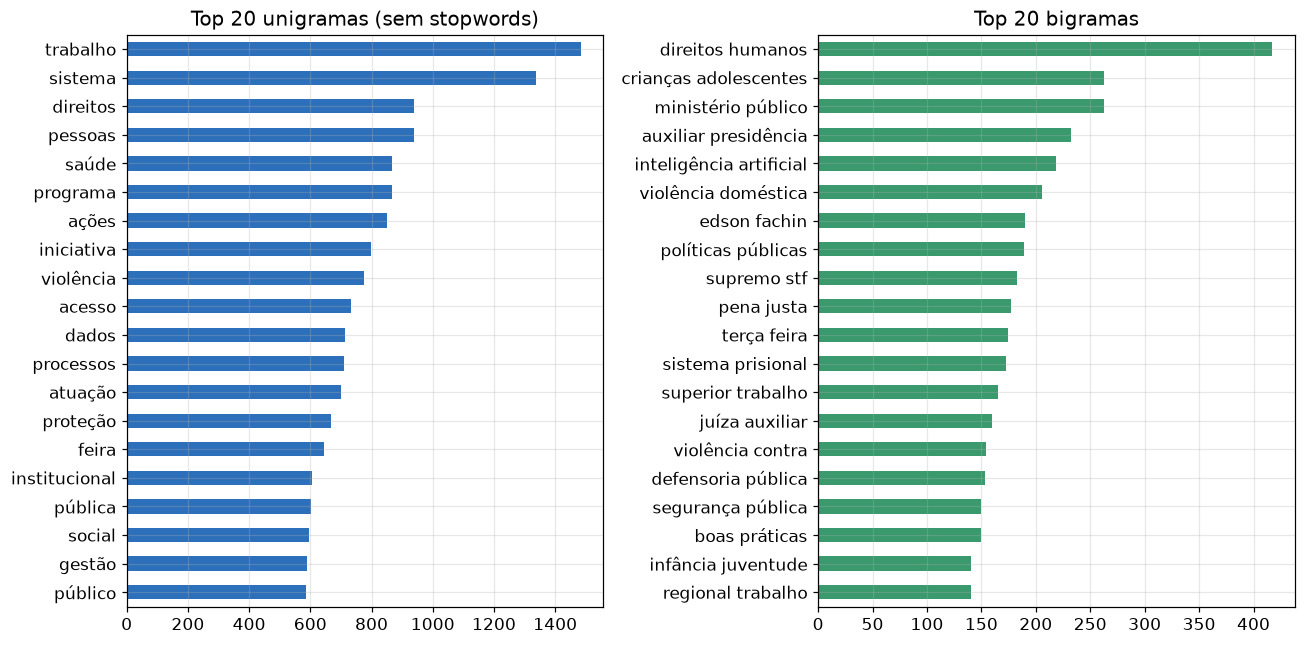

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
top_uni.sort_values().plot(kind="barh", ax=axes[0], color="#2c6fbb")
axes[0].set_title("Top 20 unigramas (sem stopwords)")
top_bi.sort_values().plot(kind="barh", ax=axes[1], color="#3a9a6d")
axes[1].set_title("Top 20 bigramas")
plt.tight_layout(); plt.savefig(FIG / "04_top_termos.png"); plt.show()

## 5. Nuvem de palavras

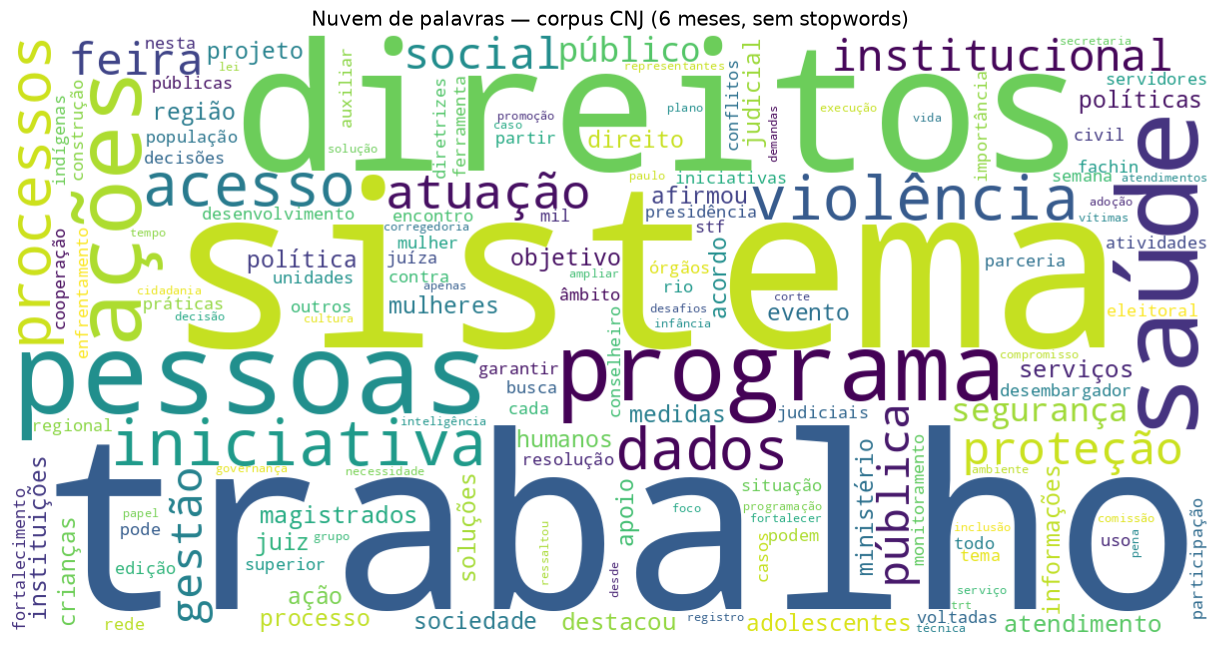

In [7]:
from wordcloud import WordCloud

freqs = {w: n for w, n in uni.items() if n >= 3}
wc = WordCloud(width=1200, height=600, background_color="white",
               colormap="viridis", max_words=150, prefer_horizontal=0.9)
wc.generate_from_frequencies(freqs)
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear"); plt.axis("off")
plt.title("Nuvem de palavras — corpus CNJ (6 meses, sem stopwords)")
plt.tight_layout(); plt.savefig(FIG / "05_wordcloud.png"); plt.show()

## 6. Volume semanal (série temporal)

Visão fina do fluxo de publicação ao longo do período — referência para a
análise de deriva temporal (Fase 5).

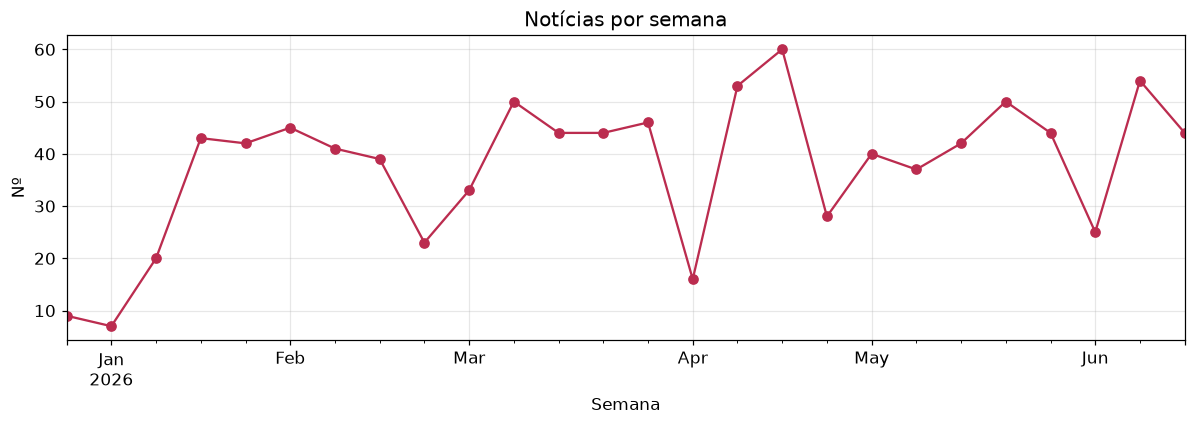

Semana de pico: 2026-04-19 -> 60 notícias


In [8]:
sem = df.set_index("data_publicacao").resample("W").size()
ax = sem.plot(figsize=(11, 4), marker="o", color="#bb2c4f")
ax.set_title("Notícias por semana"); ax.set_xlabel("Semana"); ax.set_ylabel("Nº")
plt.tight_layout(); plt.savefig(FIG / "06_volume_semanal.png"); plt.show()
print("Semana de pico:", sem.idxmax().date(), "->", int(sem.max()), "notícias")

## Síntese da EDA

- **Volume:** ~160-200 notícias/mês nos meses cheios; dez/25 parcial (janela
  inicia 21/12) e jun/26 parcial (até 19/06).
- **Categorias-fonte:** dominadas por rótulos genéricos ("Agência CNJ de
  Notícias", "Notícias CNJ", "Notícias do Judiciário") — **insuficientes para
  caracterizar pauta**, o que justifica a modelagem de tópicos (Fase 4).
- **Comprimento:** mediana ~449 tokens; cauda longa de textos mais extensos.
- **Termos:** após remover stopwords institucionais, emergem termos de pauta
  (ver figura 04 e nuvem) que orientam a interpretação dos tópicos.

> Os números exibidos vêm da execução real deste notebook sobre
> `noticias_limpo.parquet`. Figuras em `reports/figures/`.